In [34]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import time

compute_case_compare_Dz = True

if compute_case_compare_Dz:
    IzList = np.arange(20,250, 5)
    timing = [[] for i in range(len(IzList))]
    dict_results ={
    }
    for j in range(len(IzList)):
        case_name = "genfoam_comparaison_Dz"
        #User choice:
        solveConduction = False
        plot_at_z1 = [0.8]

        ########## Thermal hydraulics parameters ##########
        ## Geometric parameters
        canalType = "square"
        waterRadius = 0.0133409 # m #cote or radius if cylindrical
        fuelRadius = 0.00542310/2 # m : fuel rod radius
        gapRadius = fuelRadius + 0.0000000001  # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
        cladRadius =  0.0094996/2 # m : clad external radius
        height = 1.655 # m : height : active core height in BWRX-300 SMR

        ## Fluid parameters
        pOutlet = 14719781.65 # Pa
        tInlet = 592.75 #K
        u_inlet = 4.467092221 #m/s
        pressureDrop = 186737 #Pa/m
        falsePInlet = pOutlet - height * pressureDrop
        rhoInlet = IAPWS97(T = tInlet, P = falsePInlet*10**(-6)).rho #kg/m3
        flowArea = waterRadius ** 2 - np.pi * cladRadius ** 2
        qFlow = u_inlet * rhoInlet * flowArea # kg/m^2/s

        ## Meshing parameters:
        If = 8
        I1 = 3
        Iz1 = IzList[j] # number of control volumes in the axial direction

        ## Thermalhydraulics correlation
        voidFractionCorrel = "EPRIvoidModel"
        frfaccorel = "Churchill"
        P2Pcorel = "MNmodel"
        numericalMethod = 'FVM'

        ############ Nuclear Parameters ###########
        ## Fission parameters
        qFiss = 1943301220 # W/m3

        ## Material parameters
        kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
        Hgap = 10000
        kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
        # k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity
        ########## Algorithm parameters ###########
        nIter = 1000
        tol = 1e-4

        Qfiss1 = []
        for i in range(Iz1): 
            if i*(height/Iz1) < 0.1:
                Qfiss1.append(0)
            else:
                Qfiss1.append(qFiss)
        print(Qfiss1)
        
        start = time.time()
        voidFractionCorrel= "EPRIvoidModel"
        case1 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)
        end = time.time()
        timing[j].append(start-end)
        
        start = time.time()
        voidFractionCorrel= "GEramp"
        case2 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)
        end = time.time()
        timing[j].append(start-end)
        
        start = time.time()
        voidFractionCorrel= "modBestion"
        case3 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)
        end = time.time()
        timing[j].append(start-end)
        
        start = time.time()
        voidFractionCorrel= "HEM1"
        case4 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)
        end = time.time()
        timing[j].append(start-end)

        plotter = plotting([case1, case2, case3, case4])
        #plotter.plotComparison("numericalMethod", [True, True, True, True, True, True, True])
        genFoamVolumeFraction = 0.5655077285
        #plotter.GenFoamComp(r"C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsTransitoire\results.xlsx", 'voidFractionCorrel', [True, True, True, True, True, True], genFoamVolumeFraction)
        #plotter.compute_error(r"C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsTransitoire\results.xlsx", "voidFractionCorrel", genFoamVolumeFraction)
    
        dict_results[IzList[j]] = [case1.convection_sol.voidFraction[-1], case2.convection_sol.voidFraction[-1], case3.convection_sol.voidFraction[-1], case4.convection_sol.voidFraction[-1]]


[0, 0, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220]
$$$---------- THM: prototype, case treated : genfoam_comparaison_Dz.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.655 m with 20 axial elements.
self.I_z: 20
self.qFlow: 0.32443358926945953
self.pOutlet: 14719781.65
self.Lf: 1.655
self.r_f: 0.00271155
self.clad_r: 0.0047498
self.r_w: 0.0133409
self.Dz: 0.08275
self.dt: 0
Courant number: 0.0
Numerical Method FVM
Hydraulic diameter: 0.007579097475221116
Velocity at inlet: 0.0003244335892694595 m/s
Fission power fluid
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.29499984779105115, rho: 0.27481599159493175, xTh: 4.406249240384748
Inside resolveInversion
Inside resolveInvers

Inside resolveInversion
Convergence test, residuals: epsilon: 0.38086379666583076, rho: 0.39815382292631624, xTh: 4.406247699721915
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0032941243237483587, rho: 0.003880590526554177, xTh: 0.0009029725399656698
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0014459510344243733, rho: 0.0011891338154743302, xTh: 0.0002479026921621033
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0002280782559604892, rho: 0.00023771919522083183, xTh: 5.451524217009296e-05
Convergence reached at iteration number: 3
Pressure: [14762095.7541165  14760421.89416458 14758748.13429234 14757074.47512075
 14755400.91728132 14753727.4614164  14752054.10817939 14750380.85823512
 14748707.71226008 14747034.67094277 14745361.73498403 14743688.90509735
 14742016.18200922 14739915.76999301 14737138.48357414 14734107.76607293
 14730846.57740375 14727366.884

Convergence test, residuals: epsilon: 0.004050090447040464, rho: 0.0047565790327463615, xTh: 0.0009998689502703016
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.001060385688529227, rho: 0.0008644297948247226, xTh: 0.00021307267901356515
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0001619104349064786, rho: 0.00016777391965764878, xTh: 4.5936831576402534e-05
Convergence reached at iteration number: 3
Pressure: [14762384.00437706 14761044.92607298 14759705.91174324 14758366.9617042
 14757028.07627648 14755689.25578506 14754350.50055938 14753011.81093343
 14751673.18724583 14750334.62983992 14748996.13906394 14747657.71527099
 14746319.35881928 14744981.07007215 14743642.84939821 14742304.69717148
 14740603.04632132 14738491.39215371 14736221.37833781 14733807.27601439
 14731256.92014984 14728575.62274341 14725767.33642996 14722835.16788851
 14719781.65      ] Pa
Enthalpy: [1451838.41784842 1451836.214507

Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.427051018388826, rho: 0.43123452697270026, xTh: 5.38463669628543
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.006039372009051636, rho: 0.007076747298788723, xTh: 0.0010993499318702536
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0012484614904429466, rho: 0.0010282104984714994, xTh: 0.00025097410369865296
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0001894781080981787, rho: 0.0002006342098122117, xTh: 5.579401434802837e-05
Convergence reached at iteration number: 3
Pressure: [14763236.47321228 14762120.5986557  14761004.76848955 14759888.98289629
 14758773.24206044 14757657.54616857 14756541.8954094  14755426.28997377
 14754310.73005475 14753195.21584762 14752079.74754992 14750964.32536152
 14749848.94948461 14748733.62012381 14747618.33748614 14746503.10178113
 14745387.9

Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.39878681358353135, rho: 0.3708731212086311, xTh: 5.827192881667007
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.003987997806158527, rho: 0.004656459663079519, xTh: 0.001138229283907999
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0006584972790744603, rho: 0.0005927791678899483, xTh: 0.0001638535066404612
Convergence reached at iteration number: 2
Pressure: [14761844.79248982 14760888.1973365  14759931.63096537 14758975.09331552
 14758018.58432628 14757062.10393718 14756105.65208798 14755149.22871869
 14754192.83376953 14753236.46718094 14752280.12889363 14751323.81884851
 14750367.53698677 14749411.28324983 14748455.05757935 14747498.85991723
 14746542.69020565 14745586.54838703 14744630.43440407 14743674.3481997
 14742718.28971714 14741762.25889989 14740806.25569171 14739322.26737718
 14737869.93413752 14736366.58

...

Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 1.383687610209552, rho: 1.4667205573036908, xTh: 15.244459403685159
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.010528386240684666, rho: 0.012952170077902095, xTh: 0.0030640420611815844
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.006025081218868892, rho: 0.004984847607648211, xTh: 0.0010378587465464594
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0010042227161782434, rho: 0.0010557689877531654, xTh: 0.0002449371848257298
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 5.391688981622295e-06, rho: 4.444927389176141e-06, xTh: 1.1051833904370808e-06
Convergence reached at iteration number: 4
Pressure: [14765440.3583608  14765300.88077576 14765161.40382107 14765021.9274967
 14764882.45180265 14764742.9767389  14764603.50230545 14764464.0285

Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 1.077793142625503, rho: 1.0137134053207872, xTh: 15.400747412736877
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.010678524735439015, rho: 0.012664252960181642, xTh: 0.0029747877867640307
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0035315965723690217, rho: 0.0029041237570731886, xTh: 0.0005057951840470977
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.00043259704136402094, rho: 0.00040880789006581973, xTh: 0.00010201321159721695
Convergence reached at iteration number: 3
Pressure: [14763747.56836277 14763610.93170859 14763474.29571763 14763337.66039023
 14763201.02572671 14763064.3917274  14762927.75839265 14762791.12572276
 14762654.4937181  14762517.86237896 14762381.23170571 14762244.60169866
 14762107.97235817 14761971.34368455 14761834.71567814 14761698.08833928
 1476156

Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 1.2088829455759715, rho: 1.1937684171918814, xTh: 15.400751326747118
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.016207735607599222, rho: 0.019055998985972027, xTh: 0.0030165641246245405
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.003664882926161569, rho: 0.002955288107229013, xTh: 0.0007255334945924369
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0005161691618817142, rho: 0.0005439846344064092, xTh: 0.0001500903264997914
Convergence reached at iteration number: 3
Pressure: [14764489.91947083 14764353.28536892 14764216.65193022 14764080.01915507
 14763943.38704377 14763806.75559669 14763670.12481413 14763533.49469643
 14763396.86524394 14763260.23645697 14763123.60833587 14762986.98088097
 14762850.35409259 14762713.72797108 14762577.10251678 14762440.47773001
 14762303.85

Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 1.207867875330815, rho: 1.1921856113025957, xTh: 15.400745926986131
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.012107266636341084, rho: 0.014478303932865623, xTh: 0.0030227277122389182
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.003654625307033207, rho: 0.0029340051018600997, xTh: 0.0007226886147531119
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0005517992566067759, rho: 0.0005708179839386215, xTh: 0.00015629804048576144
Convergence reached at iteration number: 3
Pressure: [14764450.63347377 14764313.99932099 14764177.36583141 14764040.73300537
 14763904.10084321 14763767.46934524 14763630.83851181 14763494.20834324
 14763357.57883987 14763220.95000203 14763084.32183004 14762947.69432427
 14762811.06748501 14762674.44131263 14762537.81580744 14762401.19096979
 14762264.5

Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 1.402538431393276, rho: 1.4897588496033611, xTh: 15.400741651551446
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.01062372796469927, rho: 0.013088803889485783, xTh: 0.003100610025755606
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0062239397363097115, rho: 0.005136762492345766, xTh: 0.0010712395858332535
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0010262399251897173, rho: 0.0010796801736894632, xTh: 0.0002513200335702352
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 5.544056238945425e-06, rho: 4.53272465363294e-06, xTh: 1.1229276326641434e-06
Convergence reached at iteration number: 4
Pressure: [14765505.67685054 14765369.04602139 14765232.41579712 14765095.78617771
 14764959.15716316 14764822.52875344 14764685.90094856 14764549.27374

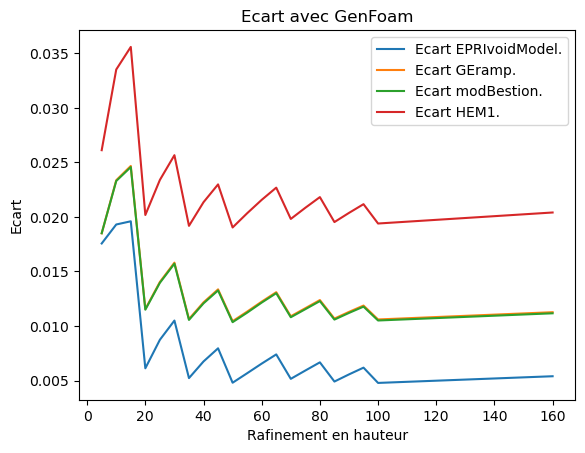

In [24]:
xDFM = [np.linspace(0, height, IzList[i]) for i in range(len(IzList))]
# Read the Excel file
df = pd.read_excel(rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\Results\GenFoamComp_Ex1_variation\variation_Iz\GFresults.xlsx')

# Create empty lists for each column
columns = df.columns.tolist()
data = [[] for _ in columns]

# Iterate over each row and append values to the corresponding list
for index, row in df.iterrows():
    for i, col in enumerate(columns):
        data[i].append(row[col])

xGenFoam = data[0]
ecart0=[]
ecart1=[]
ecart2=[]
ecart3=[]

for i in range(len(IzList)):

    # Interpolation pour la première simulation
    fraction_vide_interpolee = []
    for j in range(IzList[i]):
        fraction_vide_interpolee.append(data[1][int(j*len(data[1])/IzList[i])])

    # Calcul de l'écart entre la solution de référence et la solution interpolée
    ecart0.append(np.mean(abs(dict_results[IzList[i]][0] - fraction_vide_interpolee)))
    ecart1.append(np.mean(abs(dict_results[IzList[i]][1] - fraction_vide_interpolee)))
    ecart2.append(np.mean(abs(dict_results[IzList[i]][2] - fraction_vide_interpolee)))
    ecart3.append(np.mean(abs(dict_results[IzList[i]][3] - fraction_vide_interpolee)))

# Affichage de la différence
fig, ax = plt.subplots()
ax.plot(IzList, ecart0, label=f"Ecart {case1.convection_sol.voidFractionCorrel}.")
ax.plot(IzList, ecart1, label=f"Ecart {case2.convection_sol.voidFractionCorrel}.")
ax.plot(IzList, ecart2, label=f"Ecart {case3.convection_sol.voidFractionCorrel}.")
ax.plot(IzList, ecart3, label=f"Ecart {case4.convection_sol.voidFractionCorrel}.")
ax.set_xlabel("Rafinement en hauteur")
ax.set_ylabel("Ecart")
ax.set_title("Ecart avec GenFoam")
ax.legend(loc="best")
plt.show()

In [29]:
time1 = []
time2 = []
time3 = []
time4 = []
for i in range(len(timing)):
    time1.append(abs(timing[i][0]))
    time2.append(abs(timing[i][1]))
    time3.append(abs(timing[i][2]))
    time4.append(abs(timing[i][3]))

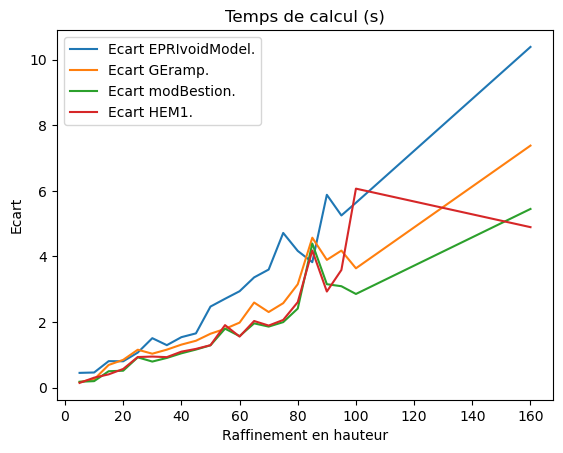

In [31]:
# Affichage de la différence
fig, ax = plt.subplots()
ax.plot(IzList, time1, label=f"Ecart {case1.convection_sol.voidFractionCorrel}.")
ax.plot(IzList, time2, label=f"Ecart {case2.convection_sol.voidFractionCorrel}.")
ax.plot(IzList, time3, label=f"Ecart {case3.convection_sol.voidFractionCorrel}.")
ax.plot(IzList, time4, label=f"Ecart {case4.convection_sol.voidFractionCorrel}.")
ax.set_xlabel("Raffinement en hauteur")
ax.set_ylabel("Ecart")
ax.set_title("Temps de calcul (s)")
ax.legend(loc="best")
plt.show()
